In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("car moving vid.mp4")

cap.set(cv2.CAP_PROP_POS_FRAMES, 170)
ret, frame1 = cap.read()

cap.set(cv2.CAP_PROP_POS_FRAMES, 195)
ret, frame2 = cap.read()

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

frame1_rgb = cv2.cvtColor(gray1, cv2.COLOR_BGR2RGB)
frame2_rgb = cv2.cvtColor(gray2, cv2.COLOR_BGR2RGB)

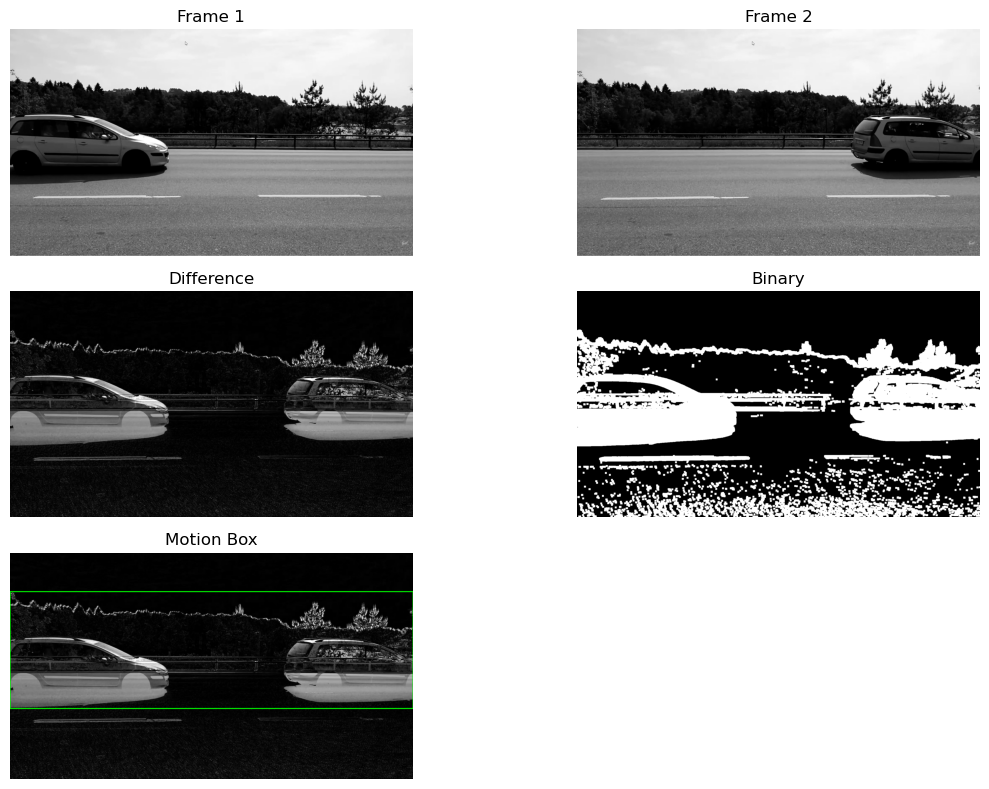

In [2]:
diff = cv2.absdiff(gray1, gray2)
_, thresh = cv2.threshold(diff, 40, 255, cv2.THRESH_BINARY)
kernel = np.ones((5,5), np.uint8)
thresh = cv2.dilate(thresh, kernel, iterations=2)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
diff_color = cv2.cvtColor(diff, cv2.COLOR_GRAY2BGR)

if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.rectangle(diff_color, (x,y), (x+w,y+h), (0,255,0), 3)

plt.figure(figsize=(12,8))

plt.subplot(3,2,1)
plt.imshow(frame1_rgb)
plt.title("Frame 1")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(frame2_rgb)
plt.title("Frame 2")
plt.axis("off")

plt.subplot(3,2,3)
plt.imshow(diff, cmap='gray')
plt.title("Difference")
plt.axis("off")

plt.subplot(3,2,4)
plt.imshow(thresh, cmap='gray')
plt.title("Binary")
plt.axis("off")

diff_rgb = cv2.cvtColor(diff_color, cv2.COLOR_BGR2RGB)
plt.subplot(3,2,5)
plt.imshow(diff_rgb)
plt.title("Motion Box")
plt.axis("off")

plt.tight_layout()
plt.show()